In [1]:
# Milestone 3 - Route and Cancellation Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_flights_dataset__.csv")


In [3]:
df.shape
df.head()
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED',
       'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
       'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [4]:
df['ROUTE'] = df['ORIGIN_AIRPORT'] + " → " + df['DESTINATION_AIRPORT']

In [5]:
df[['ORIGIN_AIRPORT','DESTINATION_AIRPORT','ROUTE']].head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE
0,ANC,SEA,ANC → SEA
1,LAX,PBI,LAX → PBI
2,SFO,CLT,SFO → CLT
3,LAX,MIA,LAX → MIA
4,SEA,ANC,SEA → ANC


In [6]:
top_routes = df['ROUTE'].value_counts().head(10)

top_routes

ROUTE
JFK → LAX    4923
LAX → JFK    4921
SFO → LAX    4911
LAX → SFO    4807
LAS → LAX    3997
LAX → LAS    3868
LGA → ORD    3859
ORD → LGA    3835
HNL → OGG    3388
OGG → HNL    3386
Name: count, dtype: int64

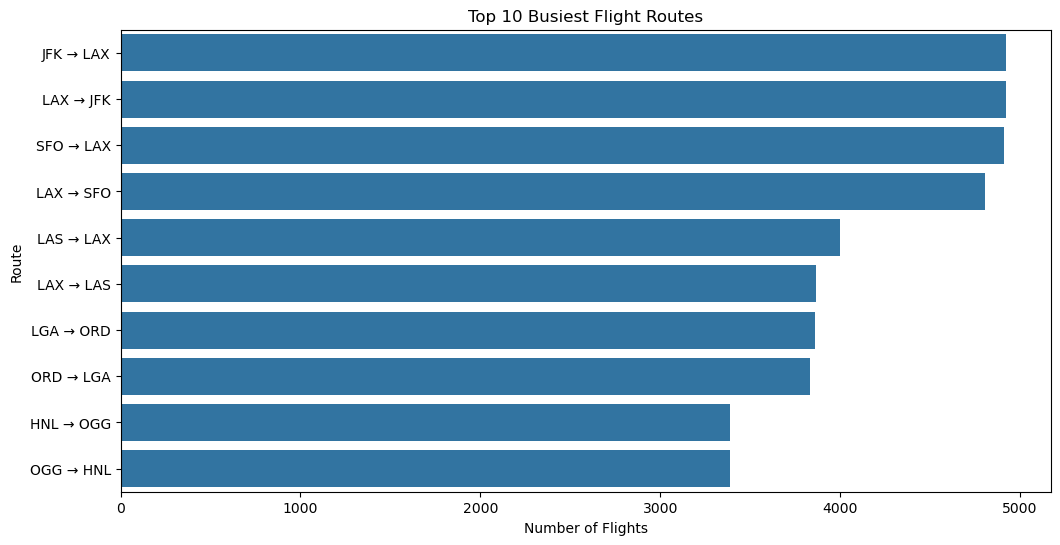

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_routes.values,
    y=top_routes.index
)

plt.title("Top 10 Busiest Flight Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.show()

In [8]:
top_origin = df['ORIGIN_AIRPORT'].value_counts().head(10)

top_origin

ORIGIN_AIRPORT
ATL    134914
ORD    108846
DFW     98583
DEN     76621
LAX     76300
IAH     59328
PHX     59229
SFO     56741
LAS     52189
MCO     45563
Name: count, dtype: int64

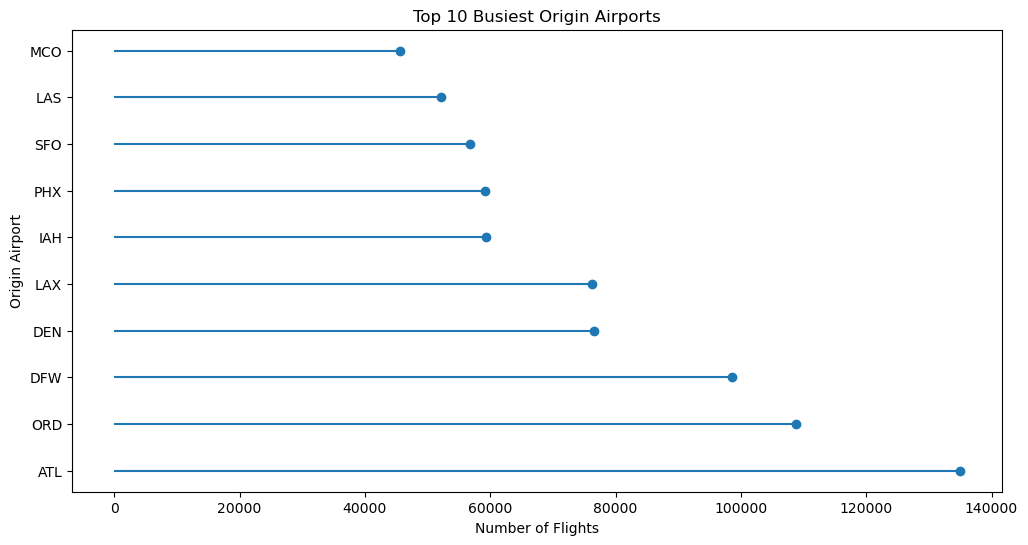

In [10]:
plt.figure(figsize=(12,6))

plt.hlines(
    y=top_origin.index,
    xmin=0,
    xmax=top_origin.values
)

plt.plot(
    top_origin.values,
    top_origin.index,
    "o"
)

plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Origin Airport")

plt.show()

In [11]:
top_dest = df['DESTINATION_AIRPORT'].value_counts().head(10)

top_dest

DESTINATION_AIRPORT
ATL    135114
ORD    109001
DFW     98697
DEN     76612
LAX     76286
IAH     59406
PHX     59209
SFO     56726
LAS     52186
MCO     45557
Name: count, dtype: int64

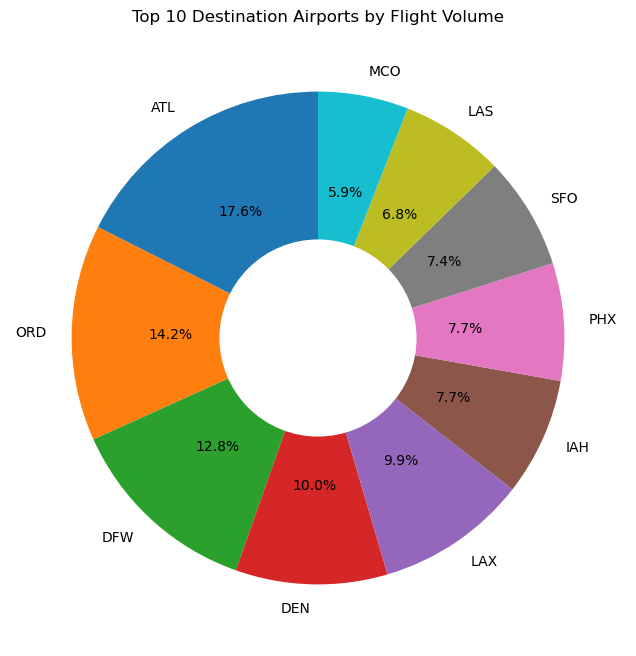

In [12]:
plt.figure(figsize=(8,8))

plt.pie(
    top_dest.values,
    labels=top_dest.index,
    autopct='%1.1f%%',
    startangle=90
)

# create donut shape
centre_circle = plt.Circle((0,0),0.40,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Top 10 Destination Airports by Flight Volume")

plt.show()

In [13]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean()

In [14]:
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(15).index

airport_delay = df[df['ORIGIN_AIRPORT'].isin(top_airports)].groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean()

In [15]:
airport_delay_df = airport_delay.to_frame()

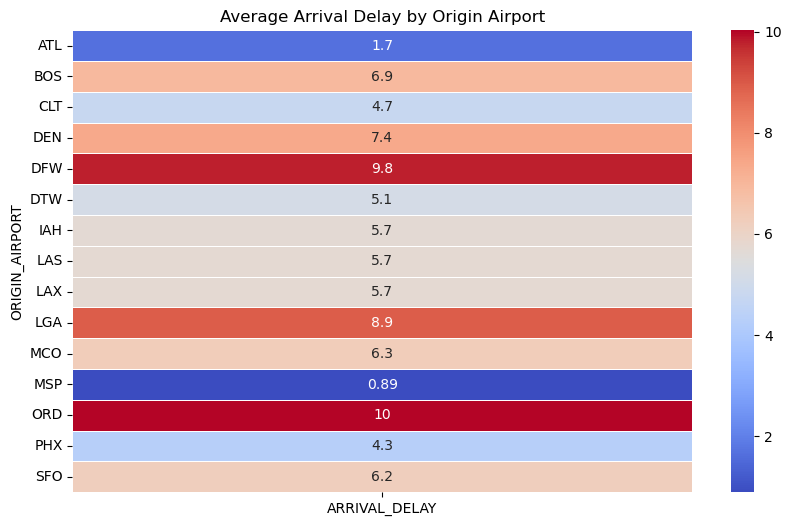

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    airport_delay_df,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Average Arrival Delay by Origin Airport")

plt.show()

In [18]:
top_routes = df['ROUTE'].value_counts().head(10).index
route_delay = df[df['ROUTE'].isin(top_routes)]

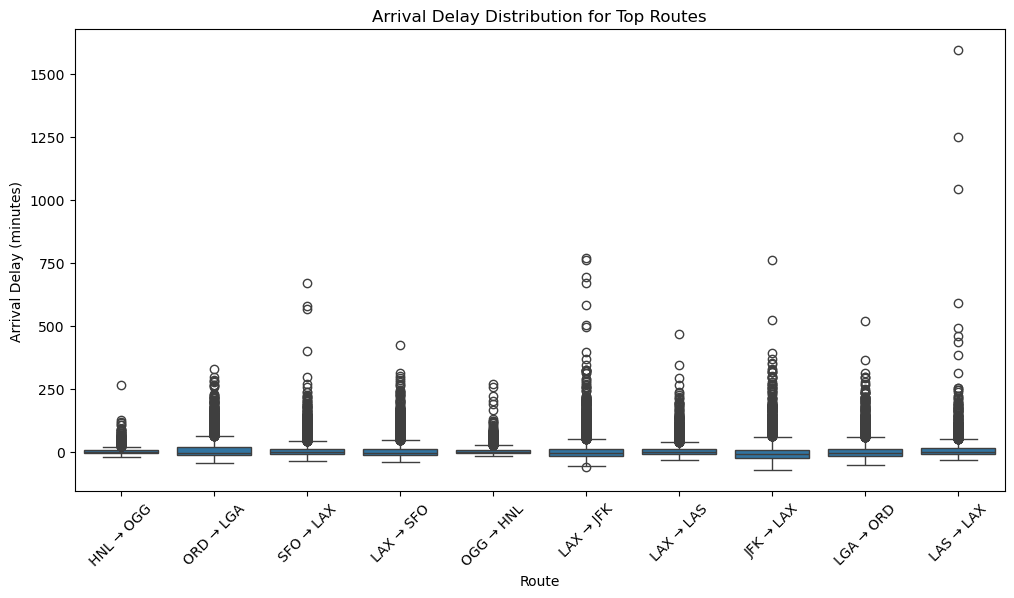

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='ROUTE',
    y='ARRIVAL_DELAY',
    data=route_delay
)

plt.xticks(rotation=45)

plt.title("Arrival Delay Distribution for Top Routes")
plt.xlabel("Route")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

In [20]:
monthly_cancel = df.groupby('MONTH')['CANCELLED'].sum()

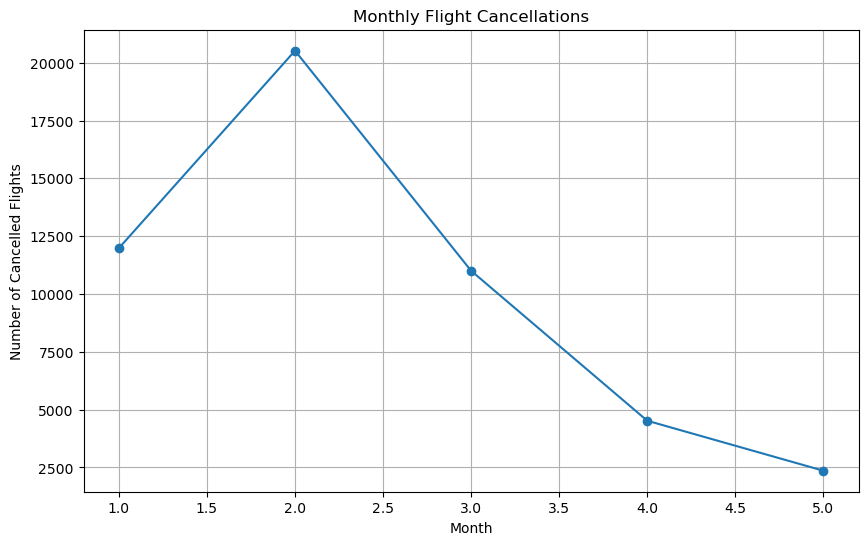

In [21]:
plt.figure(figsize=(10,6))

plt.plot(
    monthly_cancel.index,
    monthly_cancel.values,
    marker='o'
)

plt.title("Monthly Flight Cancellations")
plt.xlabel("Month")
plt.ylabel("Number of Cancelled Flights")

plt.grid(True)

plt.show()

In [23]:
cancelled_flights = df[df['CANCELLED'] == 1]
cancel_reason = cancelled_flights['CANCELLATION_REASON'].value_counts()

cancel_reason

CANCELLATION_REASON
B    32422
A    10812
C     7140
D        7
Name: count, dtype: int64

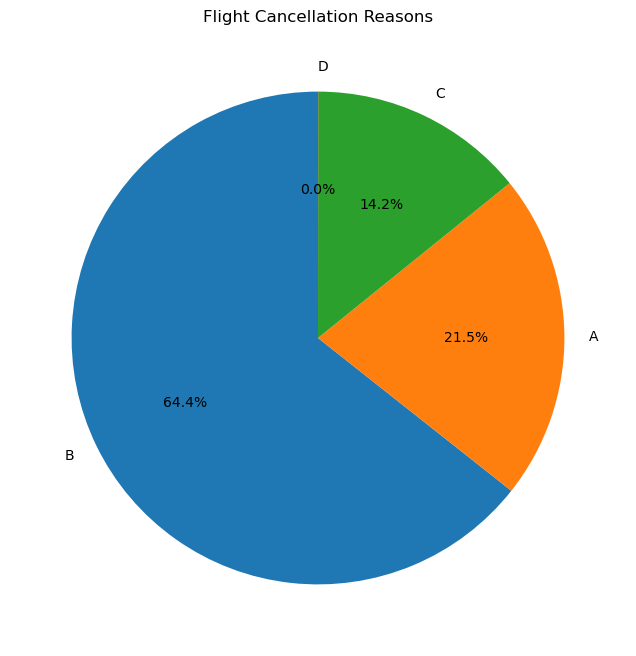

In [24]:
plt.figure(figsize=(8,8))

plt.pie(
    cancel_reason.values,
    labels=cancel_reason.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Flight Cancellation Reasons")

plt.show()

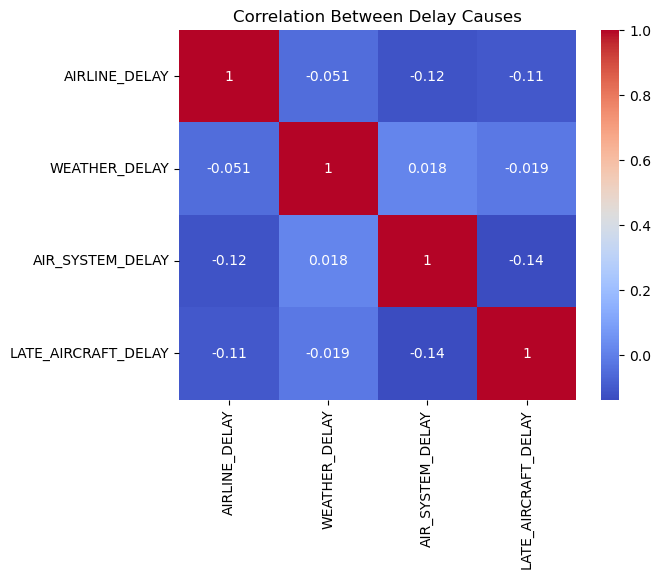

In [31]:
delay_cols = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

delay_heatmap = df[delay_cols].corr()

sns.heatmap(delay_heatmap, annot=True, cmap="coolwarm")
plt.title("Correlation Between Delay Causes")
plt.show()

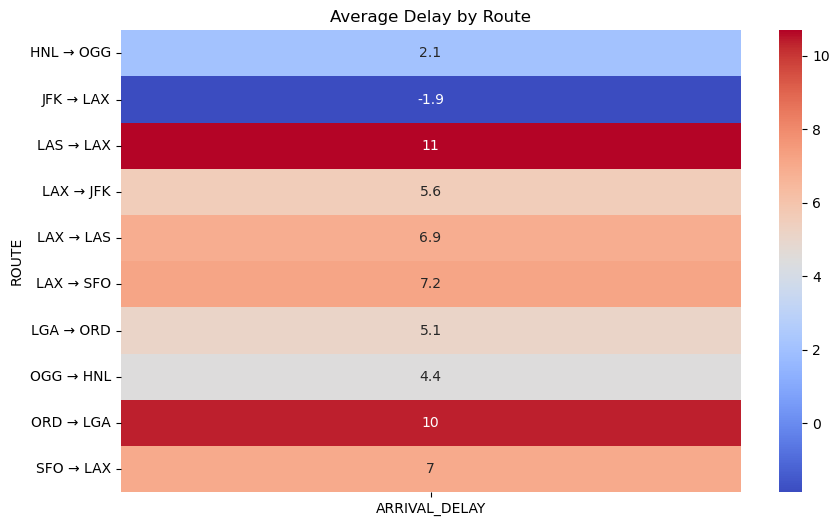

In [32]:
top_routes = df['ROUTE'].value_counts().head(10).index
route_delay = df[df['ROUTE'].isin(top_routes)]

route_delay = route_delay.groupby('ROUTE')['ARRIVAL_DELAY'].mean()

route_delay_df = route_delay.to_frame()
plt.figure(figsize=(10,6))

sns.heatmap(
    route_delay_df,
    annot=True,
    cmap="coolwarm"
)

plt.title("Average Delay by Route")

plt.show()